In [1]:
import os
import subprocess

# Check if installation was succesful.
try:
  print('Checking that the installation succeeded:')
  import mujoco
  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".')

print('Installation successful.')

# Other imports and helper functions
import time
import itertools
import numpy as np

# Graphics and plotting.
print('Installing mediapy:')
import mediapy as media
%matplotlib widget
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa
import ipywidgets as widgets


# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)

from IPython.display import clear_output
clear_output()


print(f"MuJoCo {mujoco.__version__}  |  NumPy {np.__version__}")

MuJoCo 3.9.0  |  NumPy 2.4.6


nbody = 2, nv = 6


""

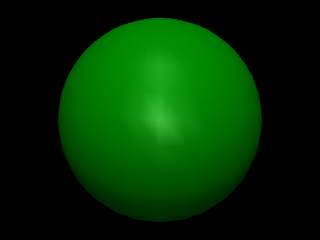

In [6]:
XML = """
<mujoco>
    <option gravity="0 0 0"/>
    
    <worldbody>
        <light name="light" pos="0 0 5" dir="0 0 -1" directional="true"/>
        
        <!-- Ball with freejoint (can rotate freely) -->
        <body name="ball" pos="0 0 0">
            <freejoint name="free"/>
            <geom type="sphere" size="0.2" rgba="0 .5 0 1" mass="1.0"/>
        </body>
    </worldbody>
    
    <actuator>
        <!-- Motor to apply torque around Z axis -->
        <motor name="motor_z" joint="free" gear="0 0 0 0 0 1" ctrlrange="-10 10"/>
    </actuator>
</mujoco>
"""


model = mujoco.MjModel.from_xml_string(XML)
data  = mujoco.MjData(model)
print(f"nbody = {model.nbody}, nv = {model.nv}")

with mujoco.Renderer(model) as renderer:
  mujoco.mj_forward(model, data)
  renderer.update_scene(data)

  media.show_image(renderer.render())

In [15]:
# Helper function to run simulation
def simulate_torque(torque_func, duration=4.0, initial_omega=0, label=""):
    """Run simulation with given torque function"""
    model = mujoco.MjModel.from_xml_string(XML)
    data = mujoco.MjData(model)
    
    data.qvel[5] = initial_omega
    
    times = []
    angle = []
    angular_vel = []
    angular_acc = []
    torque_applied = []
    
    steps = int(duration / model.opt.timestep)

    opt = mujoco.MjvOption()
    opt.frame = mujoco.mjtFrame.mjFRAME_GEOM

    frames = []
    renderer = mujoco.Renderer(model)
    
    for i in range(steps):
        t = data.time
        torque = torque_func(t)
        
        data.ctrl[0] = torque
        
        times.append(data.time)
        angle.append(data.qpos[0])
        angular_vel.append(data.qvel[5])
        angular_acc.append(data.qacc[5])
        torque_applied.append(torque)
        
        mujoco.mj_step(model, data)
        renderer.update_scene(data, scene_option=opt)
        frames.append(renderer.render())
    media.show_video(frames)
    return times, angle, angular_vel, angular_acc, torque_applied

print("✅ Setup complete!")
print(f"Ball mass: 1.0 kg")
print(f"Ball radius: 0.2 m")
print(f"Moment of inertia: I = 0.4 * m * r² = 0.016 kg·m²")

✅ Setup complete!
Ball mass: 1.0 kg
Ball radius: 0.2 m
Moment of inertia: I = 0.4 * m * r² = 0.016 kg·m²


This browser does not support the video tag.


CASE 1: ZERO TORQUE (Coasting at constant speed)
Initial angular velocity: 3.00 rad/s
Final angular velocity:   3.00 rad/s
Change in velocity:       0.00 rad/s
Mean acceleration:        0.0000 rad/s²

💡 With zero torque, angular velocity stays CONSTANT!
💡 Acceleration is ZERO!


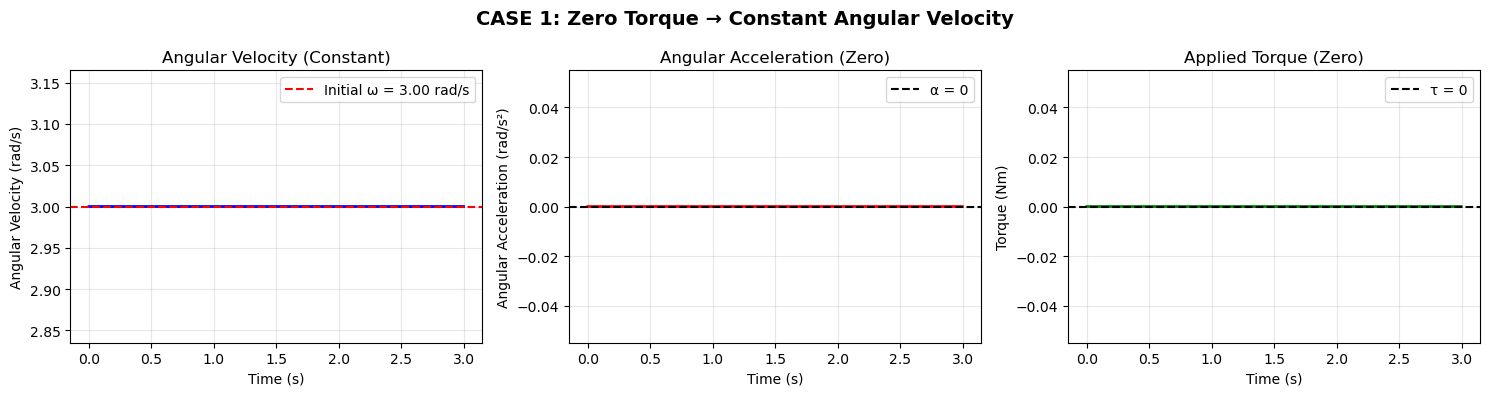

In [16]:
# Zero torque: object coasts at constant speed
def zero_torque(t):
    return 0.0

times, angle, omega, alpha, torque = simulate_torque(
    zero_torque, 
    duration=3.0, 
    initial_omega=3.0,
    label="Zero Torque"
)

print("="*60)
print("CASE 1: ZERO TORQUE (Coasting at constant speed)")
print("="*60)
print(f"Initial angular velocity: {omega[0]:.2f} rad/s")
print(f"Final angular velocity:   {omega[-1]:.2f} rad/s")
print(f"Change in velocity:       {omega[-1] - omega[0]:.2f} rad/s")
print(f"Mean acceleration:        {np.mean(alpha[100:]):.4f} rad/s²")
print("\n💡 With zero torque, angular velocity stays CONSTANT!")
print("💡 Acceleration is ZERO!")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(times, omega, 'b-', linewidth=2)
axes[0].axhline(y=omega[0], color='r', linestyle='--', label=f'Initial ω = {omega[0]:.2f} rad/s')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Angular Velocity (rad/s)')
axes[0].set_title('Angular Velocity (Constant)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(times, alpha, 'r-', linewidth=2)
axes[1].axhline(y=0, color='k', linestyle='--', label='α = 0')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Angular Acceleration (rad/s²)')
axes[1].set_title('Angular Acceleration (Zero)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(times, torque, 'g-', linewidth=2)
axes[2].axhline(y=0, color='k', linestyle='--', label='τ = 0')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Torque (Nm)')
axes[2].set_title('Applied Torque (Zero)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('CASE 1: Zero Torque → Constant Angular Velocity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

This browser does not support the video tag.


CASE 2: CONSTANT POSITIVE TORQUE (τ = 2.0 Nm)
Initial angular velocity: 0.00 rad/s
Final angular velocity:   499.75 rad/s
Change in velocity:       499.75 rad/s
Simulated acceleration:   125.0000 rad/s²
Theoretical acceleration: 125.0000 rad/s² (α = τ / I)

💡 With positive torque, angular velocity INCREASES linearly!
💡 Angular acceleration is CONSTANT!


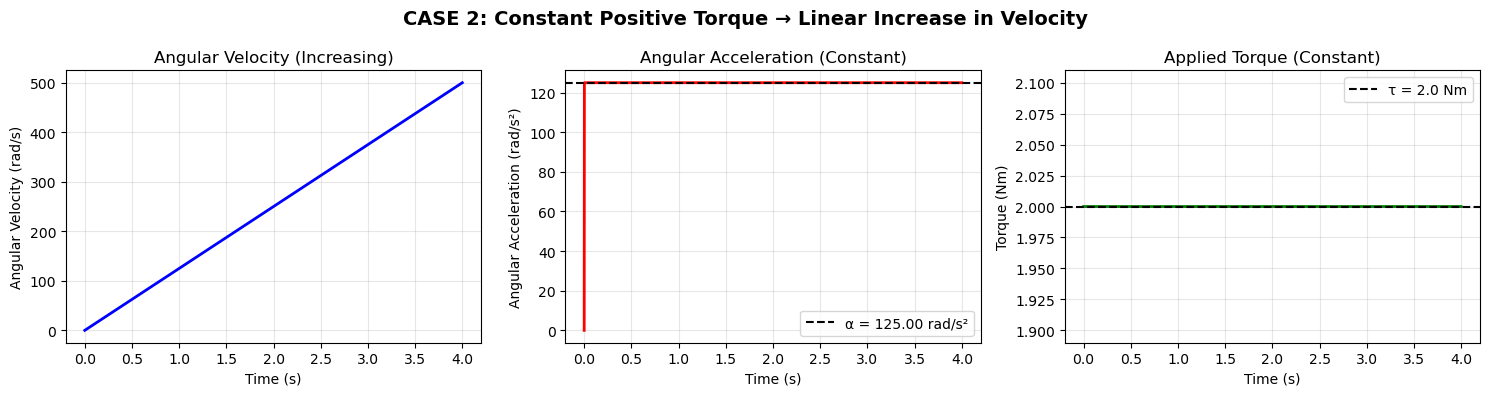

In [17]:
# Constant positive torque: object speeds up
def positive_torque(t):
    return 2.0

times, angle, omega, alpha, torque = simulate_torque(
    positive_torque, 
    duration=4.0, 
    initial_omega=0,
    label="Positive Torque"
)

# Calculate theoretical acceleration
I = 0.4 * 1.0 * 0.2**2  # I = 0.016 kg·m²
theoretical_alpha = 2.0 / I

print("="*60)
print("CASE 2: CONSTANT POSITIVE TORQUE (τ = 2.0 Nm)")
print("="*60)
print(f"Initial angular velocity: {omega[0]:.2f} rad/s")
print(f"Final angular velocity:   {omega[-1]:.2f} rad/s")
print(f"Change in velocity:       {omega[-1] - omega[0]:.2f} rad/s")
print(f"Simulated acceleration:   {np.mean(alpha[100:]):.4f} rad/s²")
print(f"Theoretical acceleration: {theoretical_alpha:.4f} rad/s² (α = τ / I)")
print("\n💡 With positive torque, angular velocity INCREASES linearly!")
print("💡 Angular acceleration is CONSTANT!")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(times, omega, 'b-', linewidth=2)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Angular Velocity (rad/s)')
axes[0].set_title('Angular Velocity (Increasing)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(times, alpha, 'r-', linewidth=2)
axes[1].axhline(y=theoretical_alpha, color='k', linestyle='--', 
                label=f'α = {theoretical_alpha:.2f} rad/s²')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Angular Acceleration (rad/s²)')
axes[1].set_title('Angular Acceleration (Constant)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(times, torque, 'g-', linewidth=2)
axes[2].axhline(y=2.0, color='k', linestyle='--', label='τ = 2.0 Nm')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Torque (Nm)')
axes[2].set_title('Applied Torque (Constant)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('CASE 2: Constant Positive Torque → Linear Increase in Velocity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

This browser does not support the video tag.


CASE 6: PULSE TORQUE (Short burst of 5 Nm at t=1.0-1.5s)
Initial angular velocity: 0.00 rad/s
Final angular velocity:   156.25 rad/s
Velocity during burst:    0.00 rad/s

💡 Short torque burst causes brief acceleration
💡 Velocity jumps up, then stays constant (coasting)


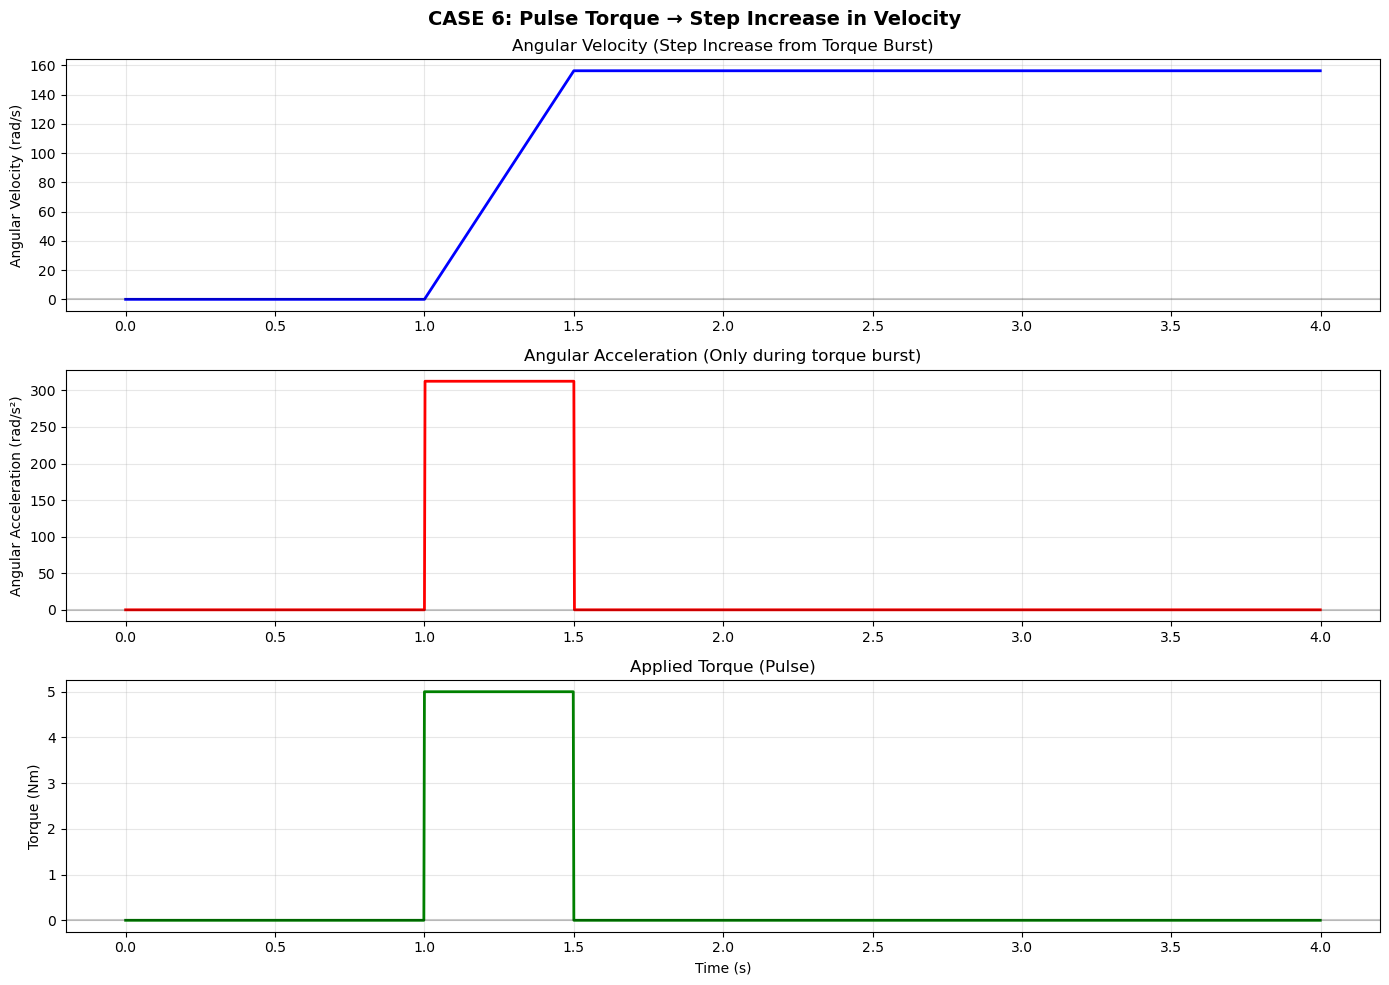

In [18]:
# Pulse torque: short burst of torque
def pulse_torque(t):
    if 1.0 < t < 1.5:
        return 5.0
    else:
        return 0.0

times, angle, omega, alpha, torque = simulate_torque(
    pulse_torque, 
    duration=4.0, 
    initial_omega=0,
    label="Pulse Torque"
)

print("="*60)
print("CASE 6: PULSE TORQUE (Short burst of 5 Nm at t=1.0-1.5s)")
print("="*60)
print(f"Initial angular velocity: {omega[0]:.2f} rad/s")
print(f"Final angular velocity:   {omega[-1]:.2f} rad/s")
print(f"Velocity during burst:    {omega[np.argmax(torque)]:.2f} rad/s")
print("\n💡 Short torque burst causes brief acceleration")
print("💡 Velocity jumps up, then stays constant (coasting)")

# Plot
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Angular Velocity
axes[0].plot(times, omega, 'b-', linewidth=2)
axes[0].axhline(y=0, color='k', linestyle='-', alpha=0.2)
axes[0].set_ylabel('Angular Velocity (rad/s)')
axes[0].set_title('Angular Velocity (Step Increase from Torque Burst)')
axes[0].grid(True, alpha=0.3)

# Angular Acceleration
axes[1].plot(times, alpha, 'r-', linewidth=2)
axes[1].axhline(y=0, color='k', linestyle='-', alpha=0.2)
axes[1].set_ylabel('Angular Acceleration (rad/s²)')
axes[1].set_title('Angular Acceleration (Only during torque burst)')
axes[1].grid(True, alpha=0.3)

# Applied Torque
axes[2].plot(times, torque, 'g-', linewidth=2)
axes[2].axhline(y=0, color='k', linestyle='-', alpha=0.2)
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Torque (Nm)')
axes[2].set_title('Applied Torque (Pulse)')
axes[2].grid(True, alpha=0.3)

plt.suptitle('CASE 6: Pulse Torque → Step Increase in Velocity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()